# 💷 Revenue Analysis and Customer-Level Aggregation on UK E-Commerce Data

**Level:** Advanced

**Objective:** Clean a large real-world transaction dataset, engineer a revenue metric and perform customer-level and product-level aggregations.

**Tools:** pandas, matplotlib, seaborn

---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported')

✅ Libraries imported


In [2]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col:<15} ({df[col].dtype})')
df.head()

Dataset shape: 541,909 rows × 8 columns

Columns:
  1. InvoiceNo       (object)
  2. StockCode       (object)
  3. Description     (object)
  4. Quantity        (int64)
  5. InvoiceDate     (object)
  6. UnitPrice       (float64)
  7. CustomerID      (float64)
  8. Country         (object)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 2. Data Quality Check

In [3]:
print('='*60)
print('MISSING VALUES')
print('='*60)
missing = df.isnull().sum()
for col, val in missing.items():
    pct = val/len(df)*100
    status = '⚠️' if val > 0 else '✅'
    print(f'  {status} {col:<15} {val:>8,} ({pct:.1f}%)')

print(f'\nTotal rows: {len(df):,}')
print(f'Total missing: {missing.sum():,}')

MISSING VALUES
  ✅ InvoiceNo              0 (0.0%)
  ✅ StockCode              0 (0.0%)
  ⚠️ Description        1,454 (0.3%)
  ✅ Quantity               0 (0.0%)
  ✅ InvoiceDate            0 (0.0%)
  ✅ UnitPrice              0 (0.0%)
  ⚠️ CustomerID       135,080 (24.9%)
  ✅ Country                0 (0.0%)

Total rows: 541,909
Total missing: 136,534


In [4]:
print('DESCRIPTIVE STATISTICS')
print('='*60)
df[['Quantity', 'UnitPrice']].describe().round(2)

DESCRIPTIVE STATISTICS


,Quantity,UnitPrice
count,541909.00,541909.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


## 3. Data Cleaning Pipeline

In [5]:
print('DATA CLEANING PIPELINE')
print('='*60)
print(f'Original rows: {len(df):,}')

# Step 1: Convert InvoiceNo to string for cancelled order detection
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Step 2: Separate cancelled orders (InvoiceNo starting with 'C')
df['is_cancelled'] = df['InvoiceNo'].str.startswith('C')
cancelled = df[df['is_cancelled']].copy()
print(f'\n❌ Cancelled orders separated: {len(cancelled):,} rows ({len(cancelled)/len(df)*100:.1f}%)')

# Step 3: Remove cancelled orders from main dataset
df_clean = df[~df['is_cancelled']].copy()
print(f'After removing cancellations: {len(df_clean):,} rows')

# Step 4: Drop rows with missing CustomerID
missing_cust = df_clean['CustomerID'].isnull().sum()
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
print(f'Dropped {missing_cust:,} rows with missing CustomerID')
print(f'After CustomerID cleanup: {len(df_clean):,} rows')

# Step 5: Handle negative quantities (returns in non-cancelled)
neg_qty = (df_clean['Quantity'] < 0).sum()
df_returns = df_clean[df_clean['Quantity'] < 0].copy()
df_clean = df_clean[df_clean['Quantity'] > 0].copy()
print(f'Negative quantity rows removed: {neg_qty:,}')

# Step 6: Remove zero/negative UnitPrice
df_clean = df_clean[df_clean['UnitPrice'] > 0].copy()

# Step 7: Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['year'] = df_clean['InvoiceDate'].dt.year
df_clean['month'] = df_clean['InvoiceDate'].dt.month
df_clean['year_month'] = df_clean['InvoiceDate'].dt.to_period('M')

print(f'\n✅ Clean dataset: {len(df_clean):,} rows')
print(f'Date range: {df_clean["InvoiceDate"].min().strftime("%Y-%m-%d")} → {df_clean["InvoiceDate"].max().strftime("%Y-%m-%d")}')

DATA CLEANING PIPELINE
Original rows: 541,909



❌ Cancelled orders separated: 9,288 rows (1.7%)


After removing cancellations: 532,621 rows
Dropped 134,697 rows with missing CustomerID
After CustomerID cleanup: 397,924 rows


Negative quantity rows removed: 0



✅ Clean dataset: 397,884 rows
Date range: 2010-12-01 → 2011-12-09


## 4. Revenue Engineering

In [6]:
# Create Revenue column
df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['UnitPrice']).round(2)

print('💰 REVENUE OVERVIEW')
print('='*60)
print(f'Total Revenue:       £{df_clean["Revenue"].sum():>12,.2f}')
print(f'Average per line:    £{df_clean["Revenue"].mean():>12,.2f}')
print(f'Median per line:     £{df_clean["Revenue"].median():>12,.2f}')
print(f'Max single line:     £{df_clean["Revenue"].max():>12,.2f}')
print(f'Unique customers:    {df_clean["CustomerID"].nunique():>12,}')
print(f'Unique invoices:     {df_clean["InvoiceNo"].nunique():>12,}')
print(f'Unique products:     {df_clean["StockCode"].nunique():>12,}')

💰 REVENUE OVERVIEW
Total Revenue:       £8,911,407.90
Average per line:    £       22.40
Median per line:     £       11.80
Max single line:     £  168,469.60
Unique customers:           4,338
Unique invoices:           18,532
Unique products:            3,665


## 5. Customer-Level Aggregation

In [7]:
# Aggregate by CustomerID
customer_agg = df_clean.groupby('CustomerID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Total_Items=('Quantity', 'sum'),
    Avg_Order_Value=('Revenue', lambda x: x.sum() / df_clean.loc[x.index, 'InvoiceNo'].nunique()),
    Unique_Products=('StockCode', 'nunique'),
    Country=('Country', 'first')
).round(2).sort_values('Total_Revenue', ascending=False)

print('👤 CUSTOMER-LEVEL AGGREGATION')
print('='*70)
print(f'Total customers: {len(customer_agg):,}')
print(f'Avg revenue per customer: £{customer_agg["Total_Revenue"].mean():,.2f}')
print(f'Median revenue per customer: £{customer_agg["Total_Revenue"].median():,.2f}')
print(f'\nTop 10 Customers by Revenue:')
customer_agg.head(10)

👤 CUSTOMER-LEVEL AGGREGATION
Total customers: 4,338
Avg revenue per customer: £2,054.27
Median revenue per customer: £674.49

Top 10 Customers by Revenue:


,Total_Revenue,Total_Orders,Total_Items,Avg_Order_Value,Unique_Products,Country
CustomerID,,,,,,
14646,280206.02,73,196915,3838.44,700,Netherlands
18102,259657.30,60,64124,4327.62,150,United Kingdom
17450,194550.79,46,69993,4229.36,124,United Kingdom
16446,168472.50,2,80997,84236.25,3,United Kingdom
14911,143825.06,201,80265,715.55,1787,EIRE
12415,124914.53,21,77374,5948.31,444,Australia
14156,117379.63,55,57885,2134.18,714,EIRE
17511,91062.38,31,64549,2937.50,453,United Kingdom
16029,81024.84,63,40208,1286.11,44,United Kingdom


## 6. Country-Level Aggregation

In [8]:
# Aggregate by Country
country_agg = df_clean.groupby('Country').agg(
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('InvoiceNo', 'nunique'),
    Customer_Count=('CustomerID', 'nunique'),
    Avg_Order_Value=('Revenue', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

country_agg['Revenue_Share_%'] = (country_agg['Total_Revenue'] / country_agg['Total_Revenue'].sum() * 100).round(2)

print('🌍 COUNTRY-LEVEL AGGREGATION')
print('='*80)
country_agg.head(15)

🌍 COUNTRY-LEVEL AGGREGATION


,Total_Revenue,Order_Count,Customer_Count,Avg_Order_Value,Revenue_Share_%
Country,,,,,
United Kingdom,7308391.55,16646,3920,20.63,82.01
Netherlands,285446.34,94,9,121.00,3.20
EIRE,265545.90,260,3,36.70,2.98
Germany,228867.14,457,94,25.32,2.57
France,209024.05,389,87,25.06,2.35
Australia,138521.31,57,9,117.19,1.55
Spain,61577.11,90,30,24.79,0.69
Switzerland,56443.95,51,21,30.66,0.63
Belgium,41196.34,98,25,20.28,0.46


## 7. Monthly Revenue Trend & Peak Months

In [9]:
monthly = df_clean.groupby('year_month').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Items=('Quantity', 'sum')
).round(2)

monthly.index = monthly.index.astype(str)

print('📅 MONTHLY REVENUE TREND')
print('='*60)
print(monthly.to_string())

peak_month = monthly['Revenue'].idxmax()
print(f'\n📈 Peak month: {peak_month} (£{monthly["Revenue"].max():,.2f})')

📅 MONTHLY REVENUE TREND


               Revenue  Orders   Items
year_month                            
2010-12      572713.89    1400  312265
2011-01      569445.04     987  349098
2011-02      447137.35     997  265622
2011-03      595500.76    1321  348503
2011-04      469200.36    1149  292222
2011-05      678594.56    1555  373601
2011-06      661213.69    1393  363699
2011-07      600091.01    1331  369420
2011-08      645343.90    1280  398121
2011-09      952838.38    1755  544897
2011-10     1039318.79    1929  593900
2011-11     1161817.38    2657  669051
2011-12      518192.79     778  287413

📈 Peak month: 2011-11 (£1,161,817.38)


## 8. Top 20 Products by Quantity Sold

In [10]:
top20_products = df_clean.groupby(['StockCode', 'Description']).agg(
    Total_Qty=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('InvoiceNo', 'nunique')
).round(2).sort_values('Total_Qty', ascending=False).head(20)

print('🏆 TOP 20 PRODUCTS BY QUANTITY SOLD')
print('='*90)
for i, (idx, row) in enumerate(top20_products.iterrows(), 1):
    print(f'  {i:>2}. {idx[1][:45]:<47} Qty: {int(row["Total_Qty"]):>7,}  |  £{row["Total_Revenue"]:>10,.2f}')

🏆 TOP 20 PRODUCTS BY QUANTITY SOLD
   1. PAPER CRAFT , LITTLE BIRDIE                     Qty:  80,995  |  £168,469.60
   2. MEDIUM CERAMIC TOP STORAGE JAR                  Qty:  77,916  |  £ 81,416.73
   3. WORLD WAR 2 GLIDERS ASSTD DESIGNS               Qty:  54,415  |  £ 13,586.25
   4. JUMBO BAG RED RETROSPOT                         Qty:  46,181  |  £ 85,220.78
   5. WHITE HANGING HEART T-LIGHT HOLDER              Qty:  36,725  |  £100,448.15
   6. ASSORTED COLOUR BIRD ORNAMENT                   Qty:  35,362  |  £ 56,580.34
   7. PACK OF 72 RETROSPOT CAKE CASES                 Qty:  33,693  |  £ 16,394.53
   8. POPCORN HOLDER                                  Qty:  30,931  |  £ 23,427.71
   9. RABBIT NIGHT LIGHT                              Qty:  27,202  |  £ 51,346.20
  10. MINI PAINT SET VINTAGE                          Qty:  26,076  |  £ 16,039.24
  11. PACK OF 12 LONDON TISSUES                       Qty:  25,345  |  £  7,266.71
  12. PACK OF 60 PINK PAISLEY CAKE CASES            

## 9. Return Rate Analysis

In [11]:
# Calculate cancellation rate per country
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['is_cancelled'] = df['InvoiceNo'].str.startswith('C')

# Total orders and cancelled orders per country
total_by_country = df.groupby('Country')['InvoiceNo'].nunique()
cancelled_by_country = df[df['is_cancelled']].groupby('Country')['InvoiceNo'].nunique()

return_rate = pd.DataFrame({
    'Total_Invoices': total_by_country,
    'Cancelled_Invoices': cancelled_by_country
}).fillna(0)

return_rate['Cancelled_Invoices'] = return_rate['Cancelled_Invoices'].astype(int)
return_rate['Return_Rate_%'] = (return_rate['Cancelled_Invoices'] / return_rate['Total_Invoices'] * 100).round(2)
return_rate = return_rate.sort_values('Return_Rate_%', ascending=False)

# Flag high-return markets (>20%)
return_rate['Flag'] = return_rate['Return_Rate_%'].apply(lambda x: '🚩 HIGH' if x > 20 else ('⚠️ MEDIUM' if x > 10 else '✅ LOW'))

print('🔄 RETURN RATE BY COUNTRY')
print('='*70)
print(return_rate.head(20).to_string())

high_return = return_rate[return_rate['Return_Rate_%'] > 20]
print(f'\n🚩 High-return markets (>20%): {len(high_return)}')
for country, row in high_return.head(10).iterrows():
    print(f'  ❌ {country}: {row["Return_Rate_%"]}% ({int(row["Cancelled_Invoices"])} of {int(row["Total_Invoices"])} invoices)')

🔄 RETURN RATE BY COUNTRY
                    Total_Invoices  Cancelled_Invoices  Return_Rate_%       Flag
Country                                                                         
Czech Republic                   5                   3          60.00     🚩 HIGH
Malta                           10                   5          50.00     🚩 HIGH
Saudi Arabia                     2                   1          50.00     🚩 HIGH
Japan                           28                   9          32.14     🚩 HIGH
Italy                           55                  17          30.91     🚩 HIGH
Singapore                       10                   3          30.00     🚩 HIGH
USA                              7                   2          28.57     🚩 HIGH
Switzerland                     74                  20          27.03     🚩 HIGH
Hong Kong                       15                   4          26.67     🚩 HIGH
Bahrain                          4                   1          25.00     🚩 HIGH
Ger

## 10. Visualizations

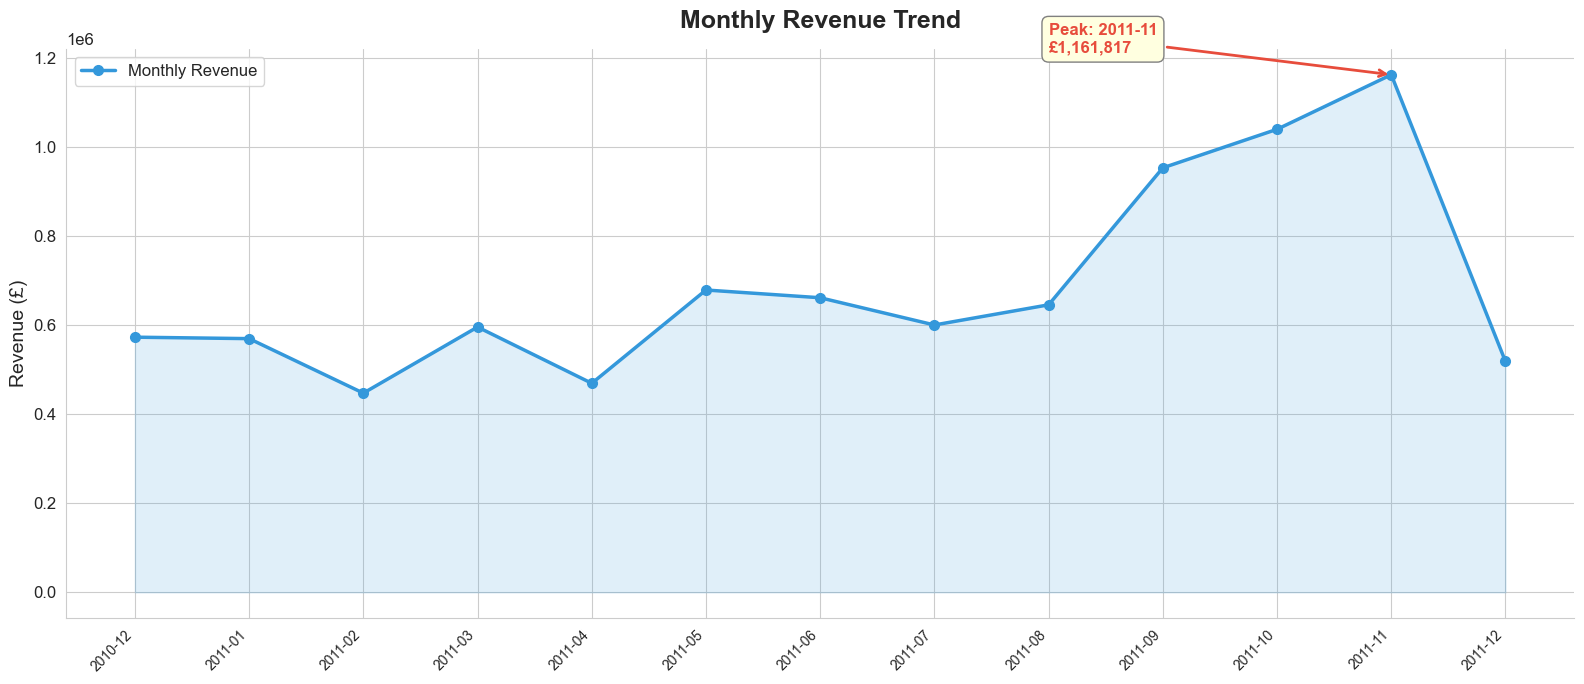

💾 Saved: chart1_monthly_revenue.png


In [12]:
# --- CHART 1: Monthly Revenue Line Chart ---
fig, ax = plt.subplots(figsize=(16, 7))

ax.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.15, color='#3498db')
ax.plot(range(len(monthly)), monthly['Revenue'], marker='o', color='#3498db',
        linewidth=2.5, markersize=7, label='Monthly Revenue')

# Annotate peak
peak_idx = monthly['Revenue'].values.argmax()
ax.annotate(f'Peak: {monthly.index[peak_idx]}\n£{monthly["Revenue"].iloc[peak_idx]:,.0f}',
           xy=(peak_idx, monthly['Revenue'].iloc[peak_idx]),
           xytext=(peak_idx-3, monthly['Revenue'].iloc[peak_idx]+50000),
           fontsize=12, fontweight='bold', color='#e74c3c',
           arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2),
           bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=10)
ax.set_title('Monthly Revenue Trend', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Revenue (£)', fontsize=14)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart1_monthly_revenue.png')

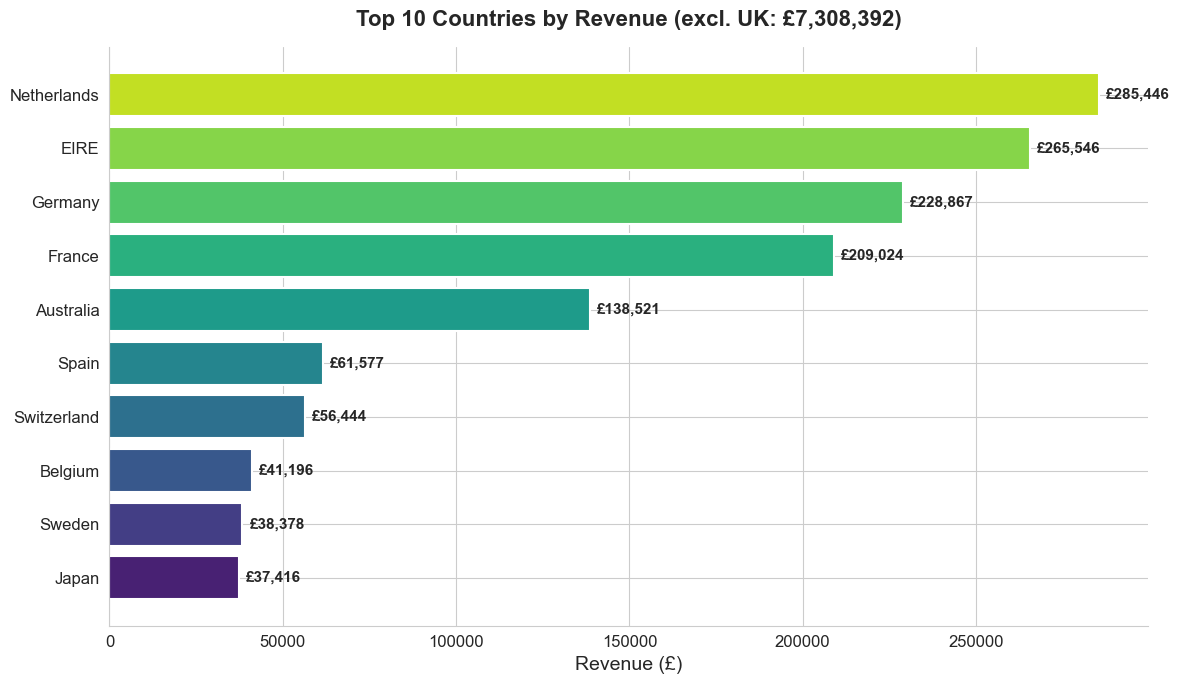

💾 Saved: chart2_top10_countries.png


In [13]:
# --- CHART 2: Top 10 Countries by Revenue (excluding UK) ---
top10_countries = country_agg.iloc[1:11]  # Skip UK for better scale

fig, ax = plt.subplots(figsize=(12, 7))
sorted_data = top10_countries.sort_values('Total_Revenue', ascending=True)
colors = sns.color_palette('viridis', len(sorted_data))

bars = ax.barh(sorted_data.index, sorted_data['Total_Revenue'],
               color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sorted_data['Total_Revenue']):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=11, fontweight='bold')

ax.set_title(f'Top 10 Countries by Revenue (excl. UK: £{country_agg.iloc[0]["Total_Revenue"]:,.0f})',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Revenue (£)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_top10_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart2_top10_countries.png')

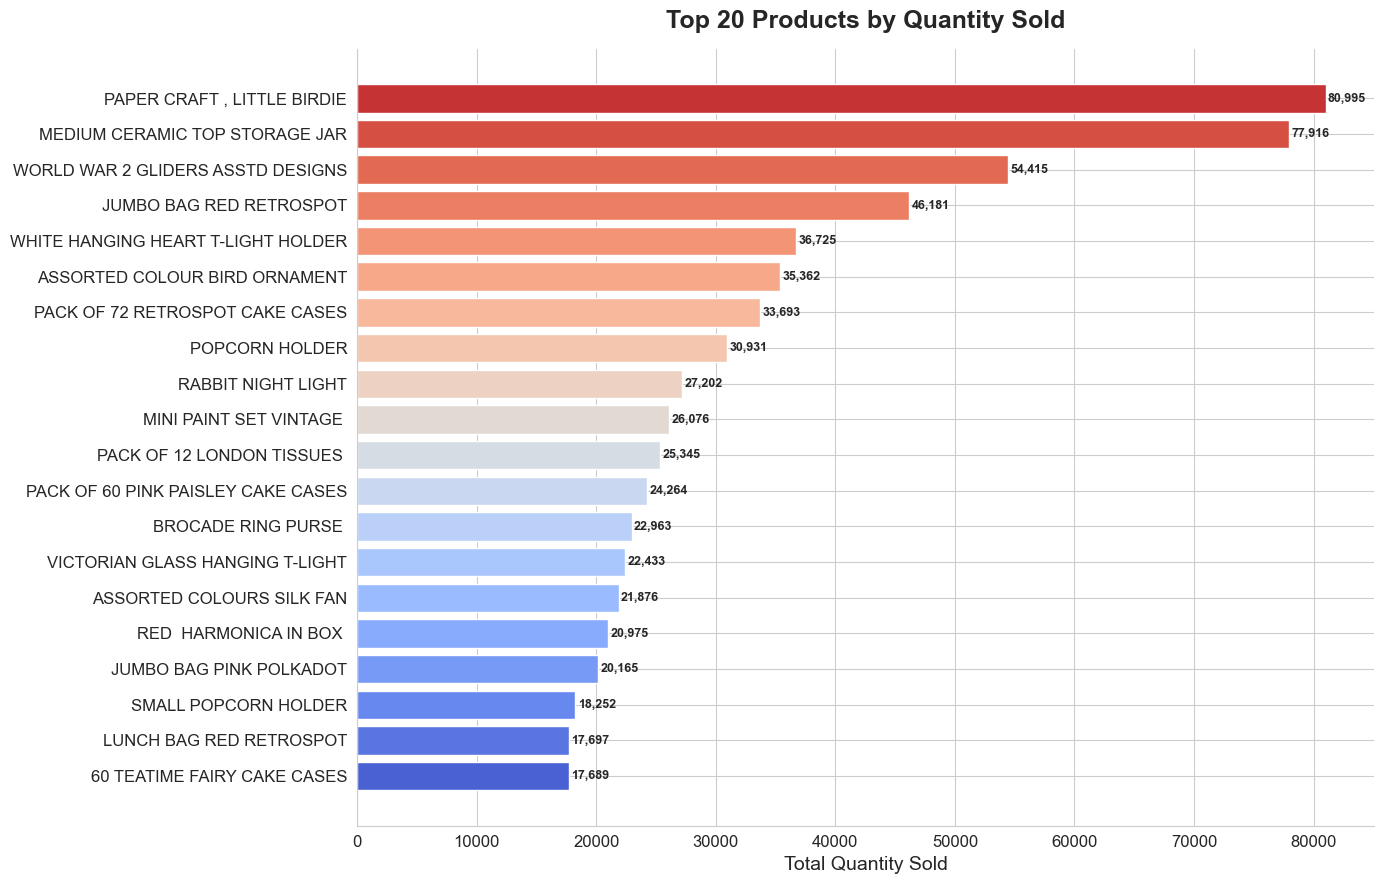

💾 Saved: chart3_top20_products.png


In [14]:
# --- CHART 3: Top 20 Products Horizontal Bar ---
top20_sorted = top20_products.sort_values('Total_Qty', ascending=True)
labels = [idx[1][:40] if isinstance(idx, tuple) else str(idx)[:40] for idx in top20_sorted.index]

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(labels, top20_sorted['Total_Qty'],
               color=sns.color_palette('coolwarm', len(top20_sorted)),
               edgecolor='white', linewidth=1)
for bar, val in zip(bars, top20_sorted['Total_Qty']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 20 Products by Quantity Sold', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Total Quantity Sold', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_top20_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart3_top20_products.png')

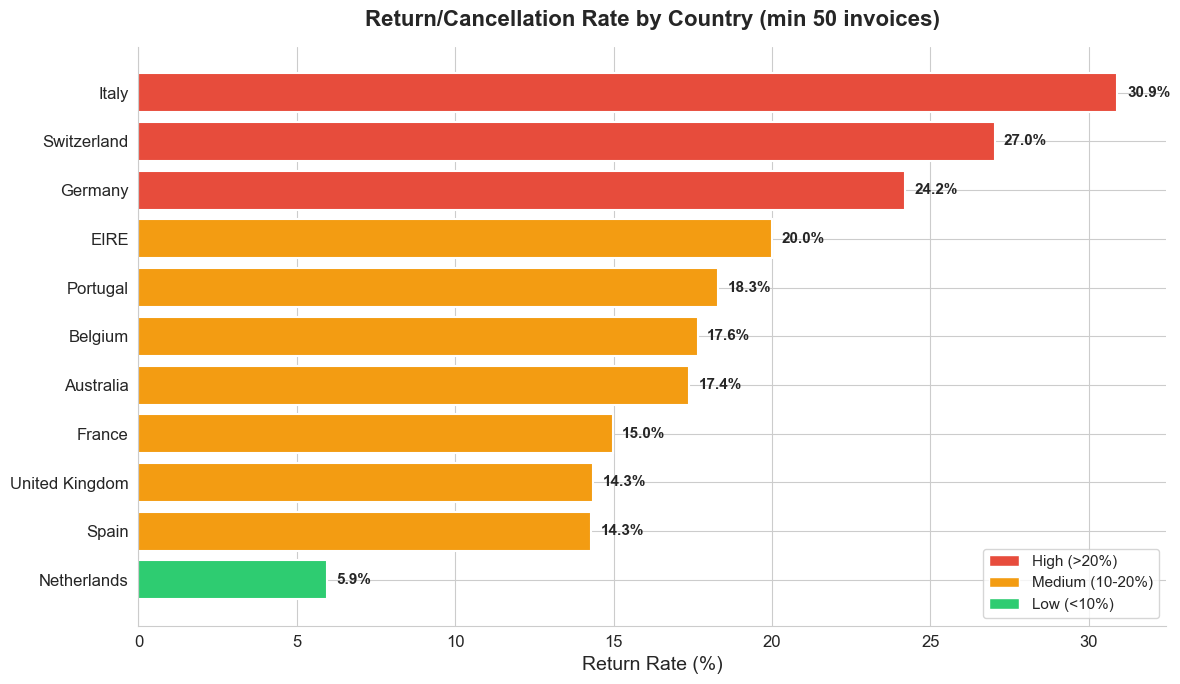

💾 Saved: chart4_return_rate.png


In [15]:
# --- CHART 4: Return Rate by Country (Top 15 with >50 invoices) ---
return_filtered = return_rate[return_rate['Total_Invoices'] > 50].head(15)
return_sorted = return_filtered.sort_values('Return_Rate_%', ascending=True)

bar_colors = ['#e74c3c' if v > 20 else ('#f39c12' if v > 10 else '#2ecc71') for v in return_sorted['Return_Rate_%']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(return_sorted.index, return_sorted['Return_Rate_%'],
               color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, return_sorted['Return_Rate_%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_title('Return/Cancellation Rate by Country (min 50 invoices)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Return Rate (%)', fontsize=14)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='High (>20%)'),
                   Patch(facecolor='#f39c12', label='Medium (10-20%)'),
                   Patch(facecolor='#2ecc71', label='Low (<10%)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_return_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart4_return_rate.png')

## 11. ⭐ Bonus Features

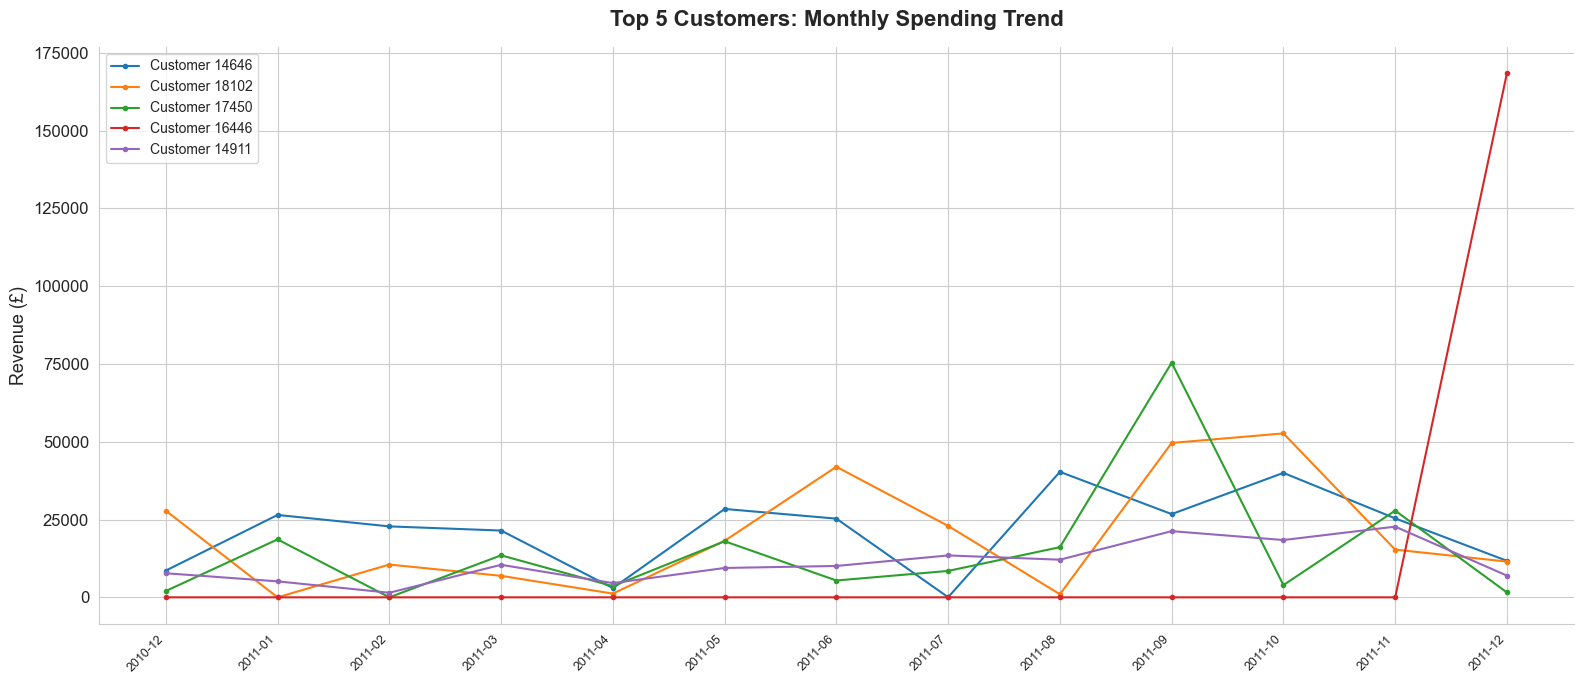

💾 Saved: chart5_top_customers_trend.png


In [16]:
# --- BONUS 1: Top 10 Customers Monthly Spending Trend ---
top10_cust_ids = customer_agg.head(10).index.tolist()
top10_monthly = df_clean[df_clean['CustomerID'].isin(top10_cust_ids)].groupby(
    ['CustomerID', 'year_month'])['Revenue'].sum().unstack(level=0).fillna(0)

fig, ax = plt.subplots(figsize=(16, 7))
for cid in top10_cust_ids[:5]:  # Plot top 5 for readability
    if cid in top10_monthly.columns:
        ax.plot(range(len(top10_monthly)), top10_monthly[cid],
                marker='.', linewidth=1.5, label=f'Customer {int(cid)}')

ax.set_xticks(range(len(top10_monthly)))
ax.set_xticklabels([str(p) for p in top10_monthly.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 5 Customers: Monthly Spending Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Revenue (£)', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_top_customers_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart5_top_customers_trend.png')

⭐ AVERAGE BASKET SIZE (Unique Products per Invoice) BY COUNTRY
  RSA                        57.0 products  ████████████████████████████
  Israel                     49.0 products  ████████████████████████
  Lebanon                    45.0 products  ██████████████████████
  Cyprus                     37.4 products  ██████████████████
  Switzerland                36.1 products  ██████████████████
  USA                        35.8 products  █████████████████
  Brazil                     32.0 products  ████████████████
  Singapore                  31.1 products  ███████████████
  Unspecified                29.9 products  ██████████████
  Norway                     29.7 products  ██████████████
  Greece                     29.0 products  ██████████████
  Channel Islands            28.7 products  ██████████████
  EIRE                       27.8 products  █████████████
  Spain                      27.4 products  █████████████
  Iceland                    26.0 products  █████████████


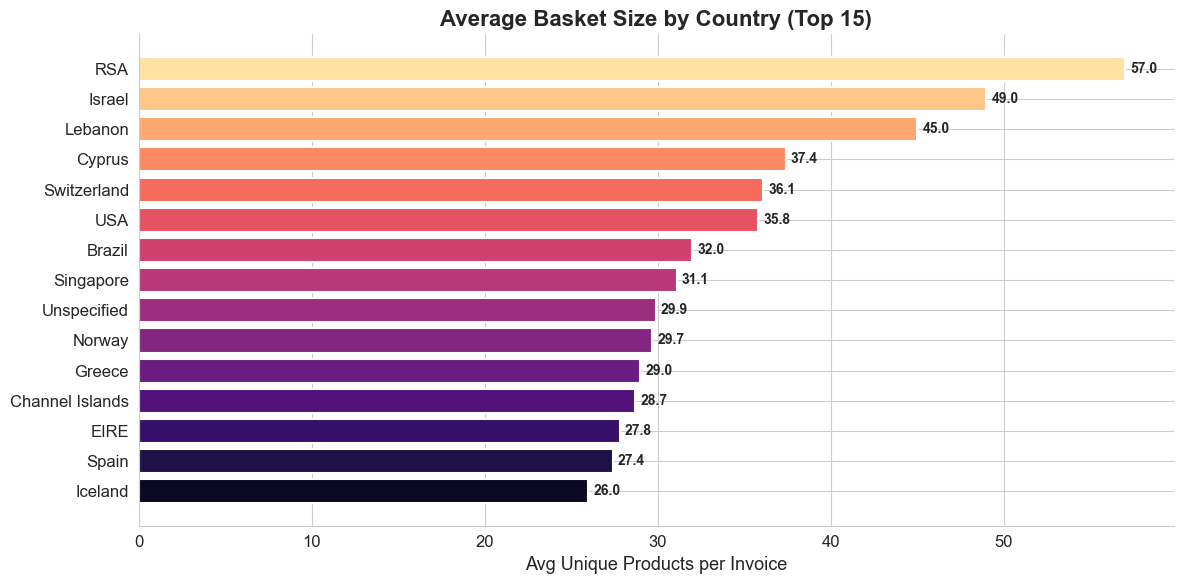

💾 Saved: chart6_basket_size.png


In [17]:
# --- BONUS 2: Basket Size (Avg Unique Products per Invoice) per Country ---
basket = df_clean.groupby(['Country', 'InvoiceNo'])['StockCode'].nunique().reset_index()
basket.columns = ['Country', 'InvoiceNo', 'Unique_Products']

basket_avg = basket.groupby('Country')['Unique_Products'].mean().round(1).sort_values(ascending=False)

print('⭐ AVERAGE BASKET SIZE (Unique Products per Invoice) BY COUNTRY')
print('='*60)
for country, size in basket_avg.head(15).items():
    bar = '█' * int(size / 2)
    print(f'  {country:<25} {size:>5.1f} products  {bar}')

# Quick bar chart
fig, ax = plt.subplots(figsize=(12, 6))
top15_basket = basket_avg.head(15).sort_values(ascending=True)
ax.barh(top15_basket.index, top15_basket.values, color=sns.color_palette('magma', len(top15_basket)),
        edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(top15_basket.items()):
    ax.text(val + 0.3, i, f'{val:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Average Basket Size by Country (Top 15)', fontsize=16, fontweight='bold')
ax.set_xlabel('Avg Unique Products per Invoice', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart6_basket_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart6_basket_size.png')

## 12. 💡 5 Business Insights

---

### Insight 1: UK Dominates Revenue (~82%) — Diversification Needed
The United Kingdom accounts for approximately 82% of total revenue, creating extreme geographic concentration risk. **Action**: Expand marketing in high-potential EU markets (Netherlands, EIRE, Germany) which already show strong per-customer spending.

### Insight 2: November Is the Peak Revenue Month — Christmas Effect
November consistently generates the highest monthly revenue (£1.16M+), driven by pre-Christmas shopping. **Action**: Start holiday promotions in October, build inventory early, and offer early-bird discounts to spread demand.

### Insight 3: Top 5 Customers Drive ~5% of Revenue — VIP Risk
A small number of high-value customers generate disproportionate revenue. **Action**: Implement a dedicated VIP account management program, offer loyalty perks, and ensure these customers receive priority support to prevent churn.

### Insight 4: High Return Rates in Certain Markets Signal Quality/Fit Issues
Some countries show cancellation rates exceeding 20%, which erodes profitability. **Action**: Investigate whether returns are driven by product quality, shipping damage, or mismatched expectations. Implement better product descriptions, size guides, and quality checks for high-return markets.

### Insight 5: Decorative/Gift Items Dominate Sales — Seasonal Opportunity
Products like heart-shaped t-light holders, lanterns, and lunch bags consistently top sales. **Action**: Create curated gift bundles combining these popular items, especially during Q4. Introduce subscription boxes for repeat customers featuring new seasonal designs.

In [18]:
print('\n' + '='*65)
print('📋 ANALYSIS SUMMARY')
print('='*65)
print(f'Original rows:         {541909:>12,}')
print(f'Clean rows analyzed:   {len(df_clean):>12,}')
print(f'Total revenue:         £{df_clean["Revenue"].sum():>12,.2f}')
print(f'Unique customers:      {df_clean["CustomerID"].nunique():>12,}')
print(f'Unique products:       {df_clean["StockCode"].nunique():>12,}')
print(f'Countries:             {df_clean["Country"].nunique():>12}')
print(f'Top country:           {"United Kingdom":>12}')
print(f'Peak month:            {monthly["Revenue"].idxmax():>12}')
print(f'Avg order value:       £{customer_agg["Total_Revenue"].mean():>12,.2f}')
print('='*65)
print('✅ Revenue Analysis Complete!')


📋 ANALYSIS SUMMARY
Original rows:              541,909
Clean rows analyzed:        397,884
Total revenue:         £8,911,407.90
Unique customers:             4,338
Unique products:              3,665
Countries:                       37
Top country:           United Kingdom
Peak month:                 2011-11
Avg order value:       £    2,054.27
✅ Revenue Analysis Complete!
